# Latent Space Analysis: Full Model vs Leave-Out-CSD Model

This notebook analyzes how modalities are organized in the latent space by:
1. Computing JS divergence between modality distributions (using KDE)
2. Computing cross-modality neighborhood overlap using k-NN
3. Computing Centered Kernel Alignment (CKA) to measure shared relational geometry


In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import pairwise_kernels
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import warnings
import itertools
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
# Load embeddings
print("Loading embeddings...")

# Full model embeddings
full_qbiolip = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/embeddings/ATOMICA_QBioLiP_test.parquet')
full_csd = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/embeddings/ATOMICA_CSD_test.parquet')

# Leave-out-CSD model embeddings
leave_out_qbiolip = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/embeddings/leave_out_CSD_QBioLiP_test.parquet')
leave_out_csd = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/embeddings/leave_out_CSD_CSD_test.parquet')

Loading embeddings...


In [15]:
DATA_DIR = '/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split'
# with open('f{DATA_DIR}/QBioLiP_test.pkl', 'rb') as f:
#     test_data = pickle.load(f)

modality_col = []
ids_col = []
MODALITY_LIST = ['PL', 'PDNA', 'PRNA', 'PP', 'Pion', 'RNAL', 'Ppeptide']
for modality in MODALITY_LIST:
    with open(f'{DATA_DIR}/{modality}_test.pkl', 'rb') as f:
        data = pickle.load(f)
        modality_col.extend([modality] * len(data))
        ids_col.extend([item['id'] for item in data])
id_to_modality = dict(zip(ids_col, modality_col))

## JS Divergence 

In [41]:
import numpy as np

def _zscore_whiten(Xa, Xb):
    """
    Z-score both modalities together (helps KDE in anisotropic/ill-scaled spaces).
    """
    X = np.vstack([Xa, Xb])
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (Xa - mu) / sd, (Xb - mu) / sd

def _bandwidth_scott(X):
    """Scott's rule-of-thumb for isotropic Gaussian KDE."""
    n, d = X.shape
    # Use pooled standard deviation across dimensions for isotropic kernel
    s = X.std(axis=0, ddof=1)
    s[s == 0] = 1.0
    sigma = float(np.mean(s))
    return sigma * n ** (-1.0 / (d + 4))

def _bandwidth_silverman(X):
    """Silverman's rule-of-thumb for isotropic Gaussian KDE."""
    n, d = X.shape
    s = X.std(axis=0, ddof=1)
    s[s == 0] = 1.0
    sigma = float(np.mean(s))
    return sigma * ( (4.0 / (d + 2)) ** (1.0 / (d + 4)) ) * n ** (-1.0 / (d + 4))

def _resolve_bandwidth(bandwidth, Xa, Xb):
    if isinstance(bandwidth, (float, int)):
        return float(bandwidth)
    X = np.vstack([Xa, Xb])
    if bandwidth == "scott":
        return _bandwidth_scott(X)
    if bandwidth == "silverman":
        return _bandwidth_silverman(X)
    raise ValueError("bandwidth must be 'scott', 'silverman', or a numeric float")

def _log_gaussian_norm_const(d, h):
    # Normalization constant for isotropic Gaussian kernel in d dims with bandwidth h
    # (2π)^{-d/2} * h^{-d}
    return -0.5 * d * np.log(2.0 * np.pi) - d * np.log(h)

def _pairwise_sq_dists(A, B):
    """
    Pairwise squared distances between rows of A (n x d) and B (m x d).
    Memory-efficient (no big intermediate tile), still vectorized.
    """
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    a2 = np.sum(A * A, axis=1, keepdims=True)
    b2 = np.sum(B * B, axis=1, keepdims=True).T
    return np.maximum(a2 + b2 - 2.0 * A @ B.T, 0.0)

def _kde_logpdf(eval_X, ref_X, h, leave_one_out=False, eps=1e-300, batch=8192):
    """
    Compute log-density of KDE with isotropic Gaussian kernel fitted on ref_X,
    evaluated at eval_X. If leave_one_out=True and eval_X is ref_X (same object
    by id), subtract self-kernel contribution.
    Returns log p(x).
    """
    n_ref, d = ref_X.shape
    log_norm = _log_gaussian_norm_const(d, h)
    log_inv_n = -np.log(n_ref - 1 if (leave_one_out and eval_X is ref_X and n_ref > 1) else n_ref)

    out = np.empty(len(eval_X), dtype=np.float64)

    for start in range(0, len(eval_X), batch):
        stop = min(start + batch, len(eval_X))
        Xb = eval_X[start:stop]
        D2 = _pairwise_sq_dists(Xb, ref_X)  # shape (b, n_ref)
        K = np.exp(-0.5 * D2 / (h * h))     # unnormalized kernels

        if leave_one_out and eval_X is ref_X:
            # subtract self contribution on the diagonal of the matching window
            # Note: Align local batch indices to original indices
            for i_local, i_global in enumerate(range(start, stop)):
                K[i_local, i_global] = 0.0

            denom = max(n_ref - 1, 1)
        else:
            denom = n_ref

        # density = (1/denom) * sum_j (const * exp(...))
        S = K.sum(axis=1)
        density = np.exp(log_norm) * (S / denom)
        density = np.maximum(density, eps)
        out[start:stop] = np.log(density)

    return out

def kl_divergence_kde(Xa, Xb, bandwidth="scott", whiten=True, eps=1e-300):
    """
    KL(P||Q) where P is KDE fit on Xa and Q is KDE fit on Xb.
    Uses leave-one-out for P when evaluating at Xa.
    """
    Xa = np.asarray(Xa, dtype=np.float64)
    Xb = np.asarray(Xb, dtype=np.float64)
    if Xa.ndim != 2 or Xb.ndim != 2 or Xa.shape[1] != Xb.shape[1]:
        raise ValueError("Xa shape [N,d], Xb shape [M,d] required with same d")

    if whiten:
        Xa, Xb = _zscore_whiten(Xa, Xb)

    h = _resolve_bandwidth(bandwidth, Xa, Xb)
    if h <= 0:
        raise ValueError("bandwidth must be > 0")

    # log p(x) with LOO (if possible) and log q(x) at Xa
    log_p = _kde_logpdf(Xa, Xa, h, leave_one_out=(Xa.shape[0] > 1), eps=eps)
    log_q = _kde_logpdf(Xa, Xb, h, leave_one_out=False, eps=eps)

    # KL ≈ E_{x~P} [log p(x) - log q(x)] ≈ average over Xa
    return float(np.mean(log_p - log_q))

def js_divergence_kde(Xa, Xb, bandwidth="scott", whiten=True, eps=1e-300):
    """
    Jensen–Shannon divergence between KDE(P) on Xa and KDE(Q) on Xb.
    Uses log-domain mixture with logaddexp to avoid under/overflow.
    """
    Xa = np.asarray(Xa, dtype=np.float64)
    Xb = np.asarray(Xb, dtype=np.float64)
    if Xa.ndim != 2 or Xb.ndim != 2 or Xa.shape[1] != Xb.shape[1]:
        raise ValueError("Xa shape [N,d], Xb shape [M,d] required with same d")

    if whiten:
        Xa, Xb = _zscore_whiten(Xa, Xb)

    h = _resolve_bandwidth(bandwidth, Xa, Xb)
    if h <= 0:
        raise ValueError("bandwidth must be > 0")

    # log-densities
    log_p_x = _kde_logpdf(Xa, Xa, h, leave_one_out=(Xa.shape[0] > 1), eps=eps)
    log_q_x = _kde_logpdf(Xa, Xb, h, leave_one_out=False, eps=eps)
    log_q_y = _kde_logpdf(Xb, Xb, h, leave_one_out=(Xb.shape[0] > 1), eps=eps)
    log_p_y = _kde_logpdf(Xb, Xa, h, leave_one_out=False, eps=eps)

    # mixture in log-space: log m = log(0.5*(p+q)) = logaddexp(log p, log q) - log 2
    log_half = -np.log(2.0)
    log_m_x = np.logaddexp(log_p_x, log_q_x) + log_half
    log_m_y = np.logaddexp(log_p_y, log_q_y) + log_half

    # JS = 0.5 * [ E_x~P log p(x)-log m(x) + E_y~Q log q(y)-log m(y) ]
    kl_p_m = np.mean(log_p_x - log_m_x)
    kl_q_m = np.mean(log_q_y - log_m_y)
    js = 0.5 * (kl_p_m + kl_q_m)

    # defensive: replace any residual NaNs (shouldn't occur now)
    if not np.isfinite(js):
        raise FloatingPointError("JS became non-finite; try larger bandwidth or PCA reduction.")

    return float(js)


In [ ]:
def plot_js_divergence_matrix(qbiolip_df, csd_df):
    modality_embeddings = {}

    qbiolip_df['modality'] = qbiolip_df['id'].map(id_to_modality)
    # some of these are NaNs not sure why the test set has NaNs
    qbiolip_df_filtered = qbiolip_df[~qbiolip_df['modality'].isna()].copy()
    qbiolip_df_filtered['modality_code'] = pd.Categorical(qbiolip_df_filtered['modality']).codes

    qbiolip_graph_embedding = np.stack(qbiolip_df_filtered['graph_embedding'].tolist())
    for modality in MODALITY_LIST:
        modality_data = qbiolip_graph_embedding[qbiolip_df_filtered['modality'] == modality]
        modality_embeddings[modality] = modality_data

    modality_embeddings['CSD'] = np.stack(csd_df['graph_embedding'].tolist())

    for modality, embedding in modality_embeddings.items():
        print(f"{modality} embedding shape: {embedding.shape}")

    js_divergence_matrix = []
    pairs = list(itertools.combinations(modality_embeddings.keys(), 2))
    for modality in modality_embeddings.keys():
        js_divergence_matrix.append([modality, modality, 0.0])
    for modality1, modality2 in tqdm(pairs, desc="Calculating JS divergences", total=len(pairs)):
        Xa = modality_embeddings[modality1]
        Xb = modality_embeddings[modality2]
        js = js_divergence_kde(Xa, Xb, bandwidth="scott", whiten=True)
        js_divergence_matrix.append([modality1, modality2, js/np.log(2)])
        js_divergence_matrix.append([modality2, modality1, js/np.log(2)])

    js_divergence_matrix = pd.DataFrame(js_divergence_matrix, columns=['modality1', 'modality2', 'js_divergence'])
    js_divergence_matrix = pd.pivot_table(js_divergence_matrix, values='js_divergence', index='modality1', columns='modality2')

    sns.clustermap(js_divergence_matrix, cmap='viridis', annot=True, fmt='.2f')
    plt.show()
    return js_divergence_matrix

PL embedding shape: (6652, 32)
PDNA embedding shape: (221, 32)
PRNA embedding shape: (144, 32)
PP embedding shape: (4603, 32)
Pion embedding shape: (5511, 32)
RNAL embedding shape: (973, 32)
Ppeptide embedding shape: (696, 32)
CSD embedding shape: (10000, 32)


Calculating JS divergences: 100%|██████████| 28/28 [00:26<00:00,  1.06it/s]


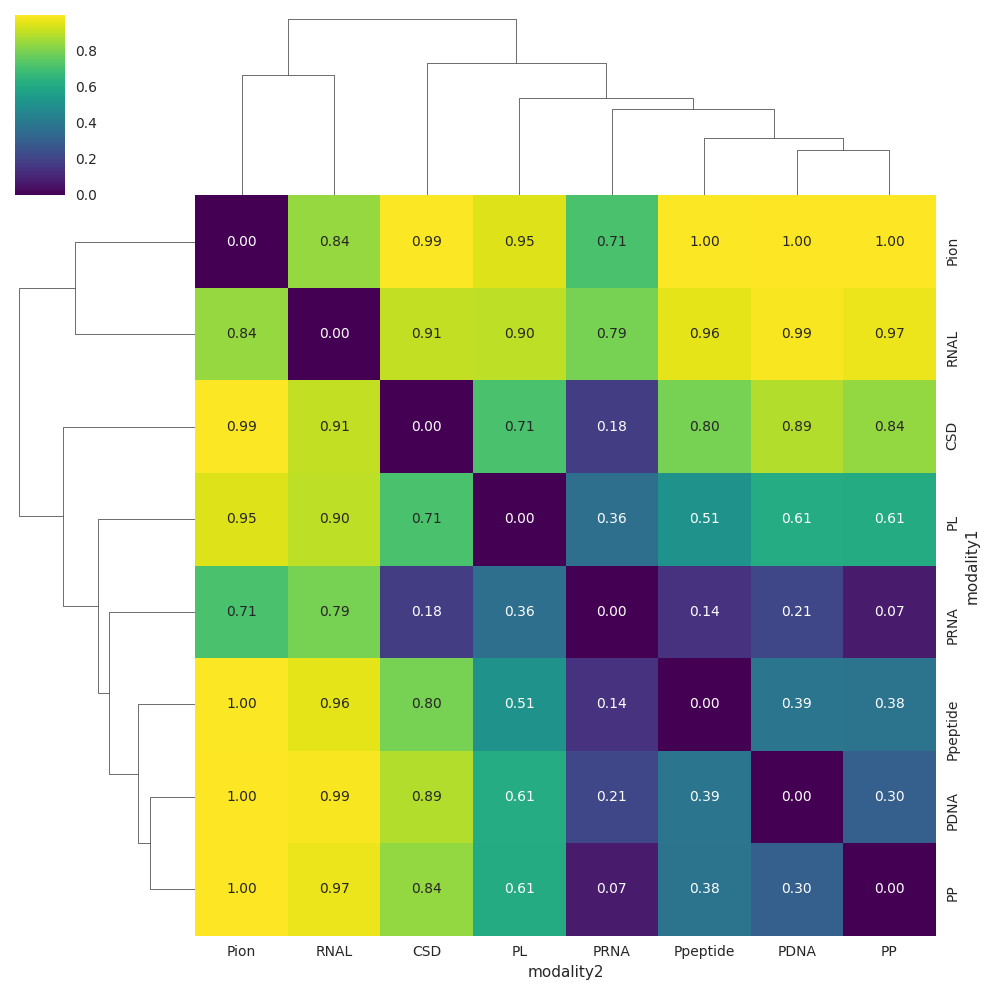

In [57]:
js_divergence_matrix = plot_js_divergence_matrix(leave_out_qbiolip, leave_out_csd)

PL embedding shape: (6652, 32)
PDNA embedding shape: (244, 32)
PRNA embedding shape: (140, 32)
PP embedding shape: (4596, 32)
Pion embedding shape: (5511, 32)
RNAL embedding shape: (973, 32)
Ppeptide embedding shape: (696, 32)
CSD embedding shape: (10000, 32)


Calculating JS divergences: 100%|██████████| 28/28 [00:26<00:00,  1.06it/s]


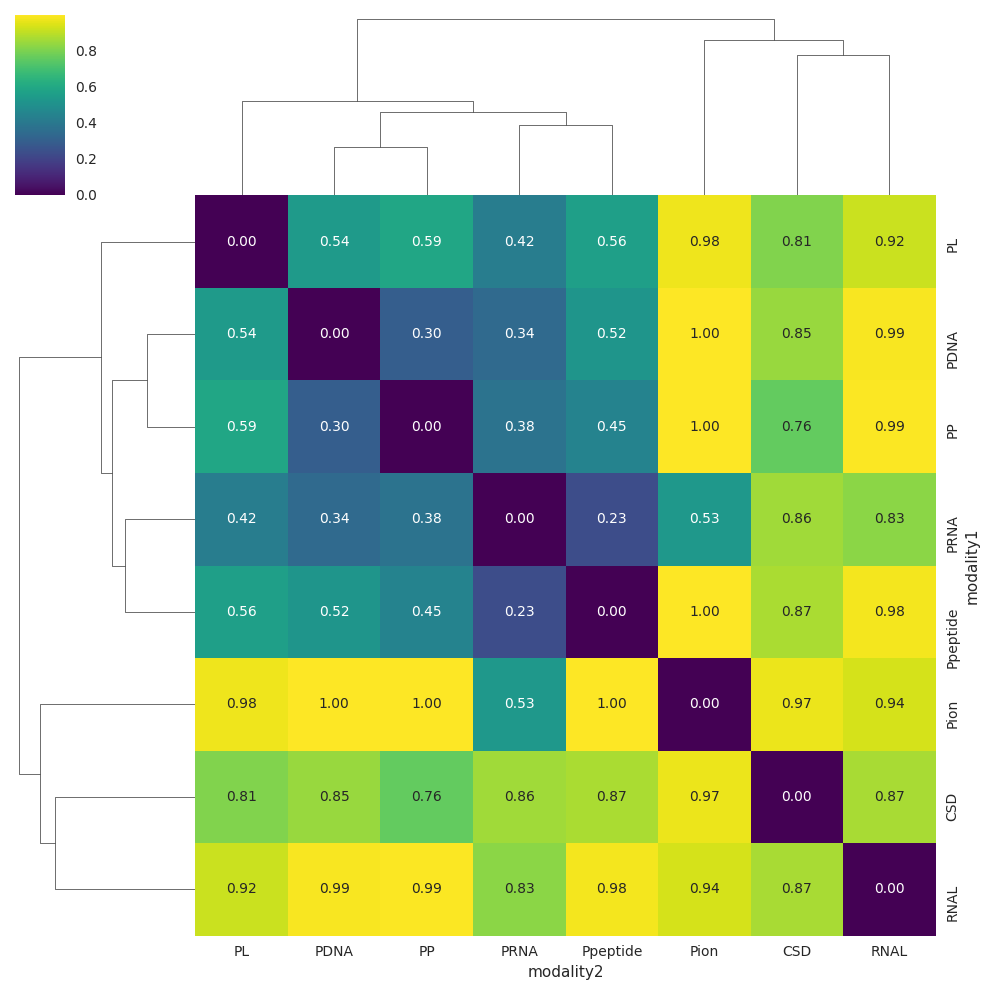

In [58]:
js_divergence_matrix = plot_js_divergence_matrix(full_qbiolip, full_csd)

## KNN Overlap (simple)

In [4]:
leave_out_qbiolip_embeddings = np.stack(leave_out_qbiolip['graph_embedding'].tolist())
full_qbiolip_embeddings = np.stack(full_qbiolip['graph_embedding'].tolist())

In [5]:
import scipy
full_qbiolip_cdist = scipy.spatial.distance.cdist(full_qbiolip_embeddings, full_qbiolip_embeddings, metric='cosine')
leave_out_qbiolip_cdist = scipy.spatial.distance.cdist(leave_out_qbiolip_embeddings, leave_out_qbiolip_embeddings, metric='cosine')

In [21]:
k = 1000
overlap_list = []
for i in tqdm(range(full_qbiolip_cdist.shape[0]), desc="Calculating KNN Overlap"):
    knn1 = np.argsort(full_qbiolip_cdist[i])[:k]
    knn2 = np.argsort(leave_out_qbiolip_cdist[i])[:k]
    overlap = np.intersect1d(knn1, knn2)
    overlap_list.append(len(overlap)-1)

Calculating KNN Overlap:   0%|          | 84/23883 [00:00<00:28, 836.75it/s]

Calculating KNN Overlap: 100%|█████████▉| 23874/23883 [00:28<00:00, 836.97it/s]


IndexError: index 23874 is out of bounds for axis 0 with size 23874

(array([ 904., 3875., 5715., 4168., 2889., 2397., 2502., 1077.,  290.,
          57.]),
 array([  0.,  27.,  54.,  81., 108., 135., 162., 189., 216., 243., 270.]),
 <BarContainer object of 10 artists>)

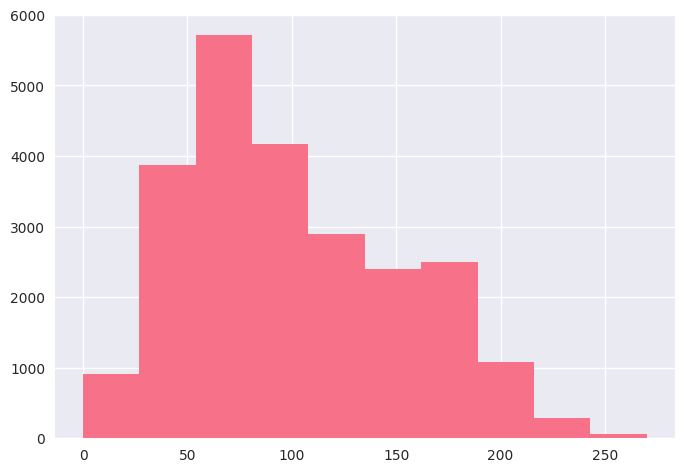

In [24]:
plt.hist(overlap_list)

In [13]:
full_qbiolip_cdist.shape

(23883, 23883)

## KNN Overlap (complex)

In [59]:
def _l2_normalize(X, eps=1e-12):
    nrm = np.linalg.norm(X, axis=1, keepdims=True)
    nrm = np.maximum(nrm, eps)
    return X / nrm

def _topk_neighbor_indices_cosine(Q, D, k, batch=16384, exclude_self_offset=None):
    """
    Return top-k indices in D for each row of Q by cosine similarity.
    Q and D must be L2-normalized already.
    If exclude_self_offset is an integer s.t. Q is a view of D[D_start:D_end],
    we will exclude the exact same row when Q and D rows match (self-neighbor).
    """
    Nq, _ = Q.shape
    Nd = D.shape[0]
    topk_idx = np.empty((Nq, k), dtype=np.int64)
    topk_sim = np.empty((Nq, k), dtype=np.float32)

    for start in range(0, Nq, batch):
        stop = min(start + batch, Nq)
        # cosine similarities = dot product (since normalized)
        S = Q[start:stop] @ D.T  # shape (b, Nd)

        if exclude_self_offset is not None:
            # mask self-similarity for the aligned rows (when Q ⊂ D contiguously)
            row_idx = np.arange(start, stop)
            S[np.arange(stop-start), row_idx + exclude_self_offset] = -np.inf

        # get top-k by partial argsort (largest sims)
        # argpartition gives indices of k largest in arbitrary order, then sort within k
        idx_part = np.argpartition(S, kth=Nd-k, axis=1)[:, -k:]          # (b,k)
        part_vals = np.take_along_axis(S, idx_part, axis=1)               # (b,k)
        order = np.argsort(-part_vals, axis=1)
        idx_sorted = np.take_along_axis(idx_part, order, axis=1)
        vals_sorted = np.take_along_axis(part_vals, order, axis=1)

        topk_idx[start:stop] = idx_sorted
        topk_sim[start:stop] = vals_sorted.astype(np.float32)

    return topk_idx, topk_sim

def cross_modality_knn_overlap(
    Xa, Xb, k=10, symmetric=True, batch=16384, return_detail=False, normalize=True
):
    """
    Cosine-similarity neighbor mixing between two modalities.
    - Xa: [N,d], Xb: [M,d]
    - k: #neighbors (excludes the query point when querying within its own modality)
    - symmetric: if True, average A→B and B→A; else only compute A→B
    - normalize: report base-rate–normalized scores in [0,1]
        observed_mix = mean fraction of cross-modality neighbors
        base = M/(N+M) for A→B (and N/(N+M) for B→A)
        normalized = (observed - base) / (1 - base)   (clipped to [0,1])
        → 0 = random mixing (no structure), 1 = perfect cross-modality mixing
        For separation tasks, you may prefer raw fractions.
    Returns a dict with:
        overlap_A_to_B, overlap_B_to_A (if symmetric), overlap_symmetric_mean
        and base rates. If return_detail, also returns per-point fractions.
    """
    Xa = np.asarray(Xa, dtype=np.float32)
    Xb = np.asarray(Xb, dtype=np.float32)
    assert Xa.ndim == 2 and Xb.ndim == 2 and Xa.shape[1] == Xb.shape[1]

    N, d = Xa.shape
    M = Xb.shape[0]
    # L2-normalize for cosine
    Xa_n = _l2_normalize(Xa)
    Xb_n = _l2_normalize(Xb)
    # Build database = [Xa; Xb]
    D = np.vstack([Xa_n, Xb_n])               # size N+M
    labels = np.r_[np.zeros(N, int), np.ones(M, int)]  # 0 for A, 1 for B

    # A → (A+B) neighbors (exclude self row by offset 0 since Q is the first N rows of D)
    topk_idx_A, _ = _topk_neighbor_indices_cosine(
        D[:N], D, k=k, batch=batch, exclude_self_offset=0
    )
    nn_labels_A = labels[topk_idx_A]                 # (N,k)
    frac_A_to_B = nn_labels_A.mean(axis=1)          # fraction of B among neighbors
    obs_A_to_B = float(frac_A_to_B.mean())

    result = {}
    base_A_to_B = M / (N + M) if (N + M) > 0 else 0.0
    if normalize:
        denom = max(1.0 - base_A_to_B, 1e-12)
        norm_A_to_B = np.clip((obs_A_to_B - base_A_to_B) / denom, 0.0, 1.0)
        result["overlap_A_to_B"] = norm_A_to_B
    else:
        result["overlap_A_to_B"] = obs_A_to_B
    result["base_A_to_B"] = base_A_to_B

    detail = {"frac_A_to_B": frac_A_to_B} if return_detail else None

    if symmetric:
        # B → (A+B) neighbors; now Q is the last M rows in D, exclude self with offset N
        topk_idx_B, _ = _topk_neighbor_indices_cosine(
            D[N:], D, k=k, batch=batch, exclude_self_offset=N
        )
        nn_labels_B = labels[topk_idx_B]
        # fraction of A among neighbors for B-queries = 1 - fraction of B
        frac_B_to_A = 1.0 - nn_labels_B.mean(axis=1)
        obs_B_to_A = float(frac_B_to_A.mean())

        base_B_to_A = N / (N + M) if (N + M) > 0 else 0.0
        if normalize:
            denom = max(1.0 - base_B_to_A, 1e-12)
            norm_B_to_A = np.clip((obs_B_to_A - base_B_to_A) / denom, 0.0, 1.0)
            result["overlap_B_to_A"] = norm_B_to_A
            result["overlap_symmetric_mean"] = 0.5 * (result["overlap_A_to_B"] + norm_B_to_A)
        else:
            result["overlap_B_to_A"] = obs_B_to_A
            result["overlap_symmetric_mean"] = 0.5 * (result["overlap_A_to_B"] + obs_B_to_A)
        result["base_B_to_A"] = base_B_to_A

        if return_detail:
            detail["frac_B_to_A"] = frac_B_to_A

    if return_detail:
        result["detail"] = detail
    return result


In [ ]:
def plot_cross_modality_knn_overlap(qbiolip_df, csd_df):
    modality_embeddings = {}

    qbiolip_df['modality'] = qbiolip_df['id'].map(id_to_modality)
    # some of these are NaNs not sure why the test set has NaNs
    qbiolip_df_filtered = qbiolip_df[~qbiolip_df['modality'].isna()].copy()
    qbiolip_df_filtered['modality_code'] = pd.Categorical(qbiolip_df_filtered['modality']).codes

    qbiolip_graph_embedding = np.stack(qbiolip_df_filtered['graph_embedding'].tolist())
    for modality in MODALITY_LIST:
        modality_data = qbiolip_graph_embedding[qbiolip_df_filtered['modality'] == modality]
        modality_embeddings[modality] = modality_data

    modality_embeddings['CSD'] = np.stack(csd_df['graph_embedding'].tolist())

    for modality, embedding in modality_embeddings.items():
        print(f"{modality} embedding shape: {embedding.shape}")

    cross_modality_overlap = []
    pairs = list(itertools.combinations(modality_embeddings.keys(), 2))
    for modality in modality_embeddings.keys():
        cross_modality_overlap.append([modality, modality, 1.0])
    for modality1, modality2 in tqdm(pairs, desc="Calculating JS divergences", total=len(pairs)):
        Xa = modality_embeddings[modality1]
        Xb = modality_embeddings[modality2]
        cross_modality_overlap_result = cross_modality_knn_overlap(Xa, Xb, k=10, symmetric=True, normalize=True)
        cross_modality_overlap.append([modality1, modality2, cross_modality_overlap_result["overlap_symmetric_mean"]])
        cross_modality_overlap.append([modality2, modality1, cross_modality_overlap_result["overlap_symmetric_mean"]])

    cross_modality_overlap = pd.DataFrame(cross_modality_overlap, columns=['modality1', 'modality2', 'js_divergence'])
    cross_modality_overlap = pd.pivot_table(cross_modality_overlap, values='js_divergence', index='modality1', columns='modality2')

    sns.clustermap(cross_modality_overlap, cmap='viridis', annot=True, fmt='.2f')
    plt.show()
    return cross_modality_overlap

In [67]:
cross_modality_knn_overlap(Xa, Xa, k=10, symmetric=True, normalize=True)

{'overlap_A_to_B': 0.09310344827586192,
 'base_A_to_B': 0.5,
 'overlap_B_to_A': 0.10402298850574687,
 'overlap_symmetric_mean': 0.0985632183908044,
 'base_B_to_A': 0.5}

In [76]:
cross_modality_knn_overlap(Xb, Xb, k=10, symmetric=True, normalize=True)

{'overlap_A_to_B': 0.10101999999999967,
 'base_A_to_B': 0.5,
 'overlap_B_to_A': 0.09948000000000001,
 'overlap_symmetric_mean': 0.10024999999999984,
 'base_B_to_A': 0.5}

In [75]:
cross_modality_knn_overlap(Xa, Xb, k=10000, symmetric=True, normalize=True)

{'overlap_A_to_B': 0.07753800700224404,
 'base_A_to_B': 0.9349289454001496,
 'overlap_B_to_A': 0.0,
 'overlap_symmetric_mean': 0.03876900350112202,
 'base_B_to_A': 0.06507105459985041}

In [72]:
Xa.shape, Xb.shape

((696, 32), (10000, 32))

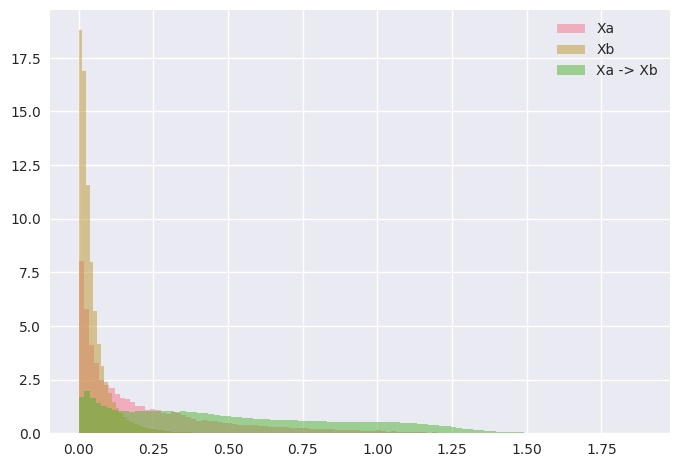

In [74]:
import scipy

xa_dist = scipy.spatial.distance.cdist(Xa, Xa, metric='cosine')
xb_dist = scipy.spatial.distance.cdist(Xb, Xb, metric='cosine')
cross_dist = scipy.spatial.distance.cdist(Xa, Xb, metric='cosine')

plt.hist(xa_dist.flatten(), bins=100, density=True, label='Xa', alpha=0.5)
plt.hist(xb_dist.flatten(), bins=100, density=True, label='Xb', alpha=0.5)
plt.hist(cross_dist.flatten(), bins=100, density=True, label='Xa -> Xb', alpha=0.5)
plt.legend()
plt.show()


PL embedding shape: (6652, 32)
PDNA embedding shape: (221, 32)
PRNA embedding shape: (144, 32)
PP embedding shape: (4603, 32)
Pion embedding shape: (5511, 32)
RNAL embedding shape: (973, 32)
Ppeptide embedding shape: (696, 32)
CSD embedding shape: (10000, 32)


Calculating JS divergences: 100%|██████████| 28/28 [00:21<00:00,  1.31it/s]


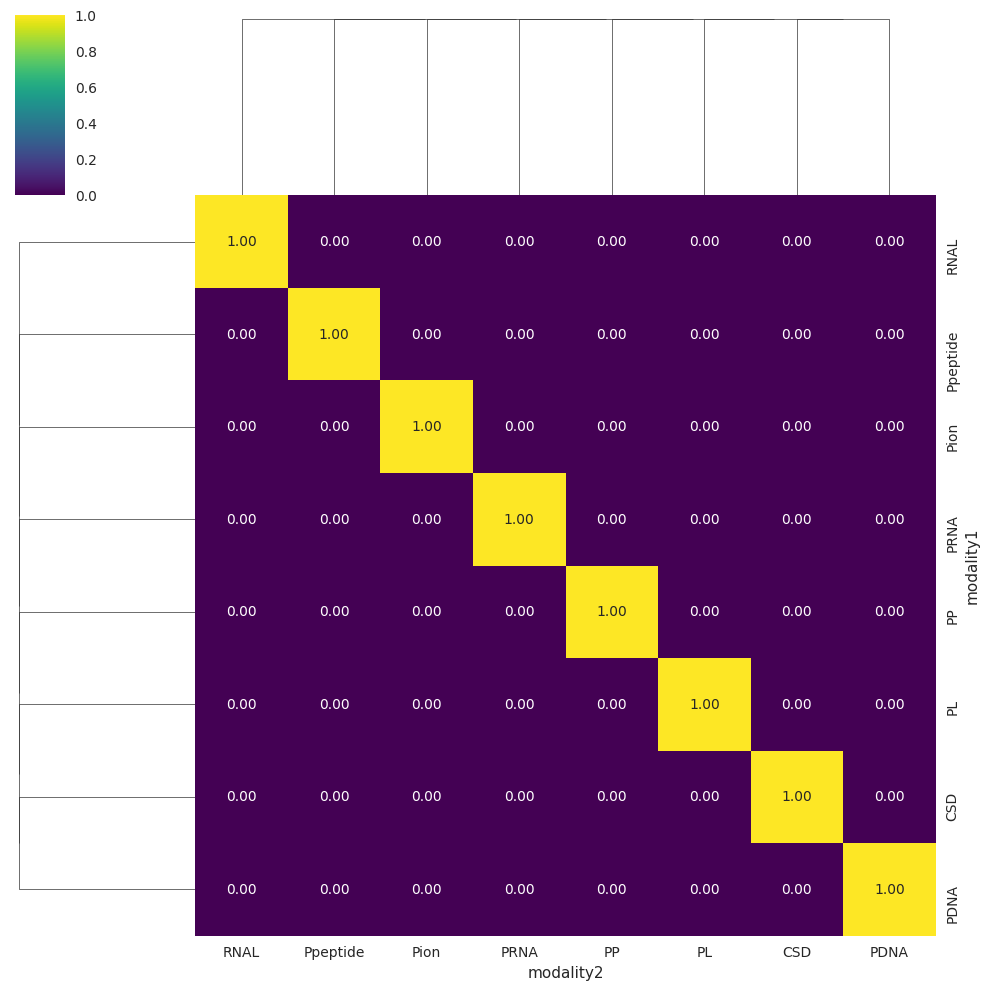

In [65]:
cross_modality_overlap = plot_cross_modality_knn_overlap(leave_out_qbiolip, leave_out_csd)

In [66]:
cross_modality_overlap

modality2,CSD,PDNA,PL,PP,PRNA,Pion,Ppeptide,RNAL
modality1,,,,,,,,
CSD,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PDNA,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
PL,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
PP,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
PRNA,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Pion,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Ppeptide,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
RNAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
